# 6G Indoor Radio Map: GCN/GAT vs. IDW/Kriging Sweep

Built from RadioGAT-inspired scaffolding, adapted to the **DeepMIMO** indoor mmWave ray-tracing dataset.

Pipeline:
1. Install dependencies
2. Load an indoor DeepMIMO scenario (point cloud + RSS + environment features)
3. Build k-NN / Delaunay graphs
4. Define GCN and GAT models
5. Define IDW and Kriging baselines
6. Run a dense/sparse x topology x model sweep (RMSE **and** coverage accuracy), across all scenarios
7. Analyze topology effects and test cross-scenario generalization (both directions)

**Before running the full sweep:** run the "list indoor scenarios" cell first, inspect the printed names, and set `SCENARIO_NAME` to a real one — the online catalog changes over time, so nothing is hardcoded.


## 1. Setup

In [1]:
import sys
print(sys.executable)

from datetime import datetime
print(datetime.now())

/home/praaneshnair/random/prism/.venv/bin/python
2026-09-14 17:15:33.557521


In [2]:
import sys

!uv pip install --python {sys.executable} deepmimo torch torch_geometric scikit-learn scipy matplotlib pykrige pandas


Audited 8 packages in 6ms


## 2. Data loading — DeepMIMO indoor scenario

Loads an indoor DeepMIMO scenario and turns it into the point-cloud format the rest of
the pipeline (graph construction, GCN/GAT, baselines) expects:

- `positions`: `(N, 3)` array of rx `(x, y, z)`
- `rss`: `(N,)` received power in dBm for one tx
- `env_feats`: `(N, F)` per-point environment features (LOS flag, distance to tx, etc.)


In [3]:
import numpy as np
import deepmimo as dm

def list_indoor_scenarios():
    """Search the live DeepMIMO catalog for indoor scenarios. Run this first
    and pick a name from the printed list -- don't hardcode a slug, the
    catalog changes."""
    results = dm.search({"environment": "indoor"})
    for r in results:
        print(r)
    return results

def load_scenario(scenario_name: str, tx_index: int = 0, max_points: int | None = 5000, seed: int = 0):
    dm.download(scenario_name)

    # Find the rx set and its total point count from the cheap params file,
    # WITHOUT loading any ray-tracing data yet.
    txrx_sets = dm.get_txrx_sets(scenario_name)
    rx_set = next(s for s in txrx_sets if s.is_rx and not s.is_tx)  # adjust if there are multiple pure-rx sets
    n_points = rx_set.num_points

    if max_points is not None and n_points > max_points:
        rng = np.random.default_rng(seed)
        keep = np.sort(rng.choice(n_points, size=max_points, replace=False))
        rx_sets_param = {rx_set.id: keep}
        print(f"Subsampled {scenario_name}: {n_points} -> {max_points} rx points (at load time).")
    else:
        rx_sets_param = "rx_only"
        keep = np.arange(n_points)

    # Only THESE rx points' ray data is ever read from disk.
    dataset = dm.load(scenario_name, rx_sets=rx_sets_param)

    # dm.load() returns a MacroDataset -- a list-like wrapper holding one
    # Dataset per active transmitter -- whenever the scenario has more than
    # one tx (e.g. "i1_2p5"). `tx_index` is meant to pick WHICH transmitter to
    # build the radio map for, so select it here, before touching anything
    # else. Scenarios with a single tx (e.g. "i2_28b") already get a plain
    # Dataset back from dm.load(), so there's nothing to select in that case --
    # this is why the bug didn't show up until a multi-tx scenario was used.
    if isinstance(dataset, dm.MacroDataset):
        dataset = dataset.datasets[tx_index]

    positions = np.asarray(dataset.rx_pos)
    channels = dataset.compute_channels()  # [n_users, n_rx_ant, n_tx_ant, n_paths]
    # Average received power over rx antennas, tx antennas, and paths.
    power_lin = np.mean(np.abs(channels) ** 2, axis=(1, 2, 3))
    rss_dbm = 10 * np.log10(power_lin + 1e-15)

    tx_pos = np.asarray(dataset.tx_pos).reshape(-1)[:3]
    dist_to_tx = np.linalg.norm(positions - tx_pos, axis=1)
    los_flag = np.asarray(dataset.los).astype(float) if hasattr(dataset, "los") else np.ones(len(positions))
    env_feats = np.stack([dist_to_tx, los_flag], axis=1)

    return positions, rss_dbm, env_feats

### 2a-i. Patch for legacy DeepMIMO scene schema

`i1_2p5` ships with an older `objects.json` schema (pre-triangulated hull) that
this version of `deepmimo`'s `Scene.from_data()` doesn't parse. This patch
detects that schema and reconstructs the `Scene` manually; scenarios with the
current schema (e.g. `i2_28b`) fall through to the original loader unchanged.

Run this once, before loading **any** scenario -- it needs to be active
before `i1_2p5` is touched by `sweep_full()` or `full_generalization_sweep()`
later in the notebook.


In [4]:
import json, os
import numpy as np
import scipy.io
from deepmimo.core.scene import Scene, PhysicalElement, Face


def _build_scene_from_legacy_triangulated_hull(base_folder):
    """Reconstruct a Scene for the older schema where objects.json groups
    row-indices into an already-triangulated faces.mat / materials.mat pair,
    instead of the 'face_vertex_idxs' or 'mesh_key' formats this deepmimo
    version's Scene.from_data() knows how to parse."""
    with open(f"{base_folder}/objects.json") as f:
        objects_metadata = json.load(f)

    vertices = scipy.io.loadmat(f"{base_folder}/vertices.mat", squeeze_me=True)["vertices"]
    tri_vertex_idxs = scipy.io.loadmat(f"{base_folder}/faces.mat", squeeze_me=True)["faces"]
    tri_material_idxs = scipy.io.loadmat(f"{base_folder}/materials.mat", squeeze_me=True)["materials"]

    scene = Scene()
    for obj_data in objects_metadata:
        faces = []
        for tri_group in obj_data["faces"]:
            for tri_idx in tri_group:
                v_idx = tri_vertex_idxs[tri_idx]
                faces.append(Face(
                    vertices=vertices[v_idx],
                    material_idx=tri_material_idxs[tri_idx],
                ))
        obj = PhysicalElement(
            faces=faces,
            object_id=obj_data.get("id", -1),
            label=obj_data.get("label", "objects"),
        )
        scene.add_object(obj)
    return scene


# Guard so this cell is safe to re-run: without this check, a second run would
# capture the ALREADY-patched Scene.from_data as "_orig_from_data", and the
# non-legacy branch below would then call the patch itself forever
# (RecursionError: maximum recursion depth exceeded).
if not getattr(Scene.from_data, "_is_legacy_hull_patch", False):
    _orig_from_data = Scene.from_data  # keep the real one as a fallback for other scenarios

    def _patched_from_data(cls, base_folder):
        objects_path = f"{base_folder}/objects.json"
        if os.path.exists(objects_path):
            with open(objects_path) as f:
                sample = json.load(f)
            if sample and "faces" in sample[0] \
                    and "mesh_key" not in sample[0] \
                    and "face_vertex_idxs" not in sample[0]:
                print(f"[info] {base_folder}: legacy triangulated-hull schema detected "
                      "-- building Scene manually.")
                return _build_scene_from_legacy_triangulated_hull(base_folder)
        return _orig_from_data(base_folder)

    _patched_from_data._is_legacy_hull_patch = True
    Scene.from_data = classmethod(_patched_from_data)
else:
    print("[info] legacy-schema patch already active -- skipping re-patch.")


### 2a. List live indoor scenarios (run this first)

In [5]:
list_indoor_scenarios()


i1_2p5
i2_28b


['i1_2p5', 'i2_28b']

### 2b. Pick a scenario name from the list above, then load it

In [6]:
SCENARIO_NAME = "i2_28b"

pos, rss, feats = load_scenario(SCENARIO_NAME)
print(pos.shape, rss.shape, feats.shape)


Scenario "i2_28b" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 41.46it/s]

(5000, 3) (5000,) (5000, 2)


In [7]:
def fit_normalizer(positions, feats, rss, idx=None):
    """Fit mean/std stats on the given subset of points (or all points if
    idx is None). Always fit on the TRAIN split only -- fitting on the
    full dataset (train+test, or on a test scenario) leaks information
    the model shouldn't have access to."""
    if idx is None:
        idx = np.arange(len(positions))
    return {
        "pos_mean": positions[idx].mean(0), "pos_std": positions[idx].std(0) + 1e-8,
        "feats_mean": feats[idx].mean(0), "feats_std": feats[idx].std(0) + 1e-8,
        "rss_mean": rss[idx].mean(), "rss_std": rss[idx].std() + 1e-8,
    }


def apply_normalizer(positions, feats, rss, stats):
    pos_n = (positions - stats["pos_mean"]) / stats["pos_std"]
    feats_n = (feats - stats["feats_mean"]) / stats["feats_std"]
    rss_n = (rss - stats["rss_mean"]) / stats["rss_std"]
    return pos_n, feats_n, rss_n


def denormalize_rss(rss_n, stats):
    return rss_n * stats["rss_std"] + stats["rss_mean"]


## 3. Graph construction — k-NN and Delaunay

Two interchangeable edge-construction functions, both returning an `edge_index`
of shape `(2, num_edges)` in the format `torch_geometric` expects.


In [8]:
from scipy.spatial import Delaunay
from sklearn.neighbors import kneighbors_graph

def knn_graph(positions: np.ndarray, k: int = 6):
    adj = kneighbors_graph(positions, n_neighbors=k, mode="connectivity", include_self=False)
    adj = adj.maximum(adj.T)  # symmetrize
    coo = adj.tocoo()
    edge_index = np.vstack([coo.row, coo.col])
    return edge_index

def delaunay_graph(positions: np.ndarray):
    # Delaunay works on the 2D (x, y) footprint; z is usually near-constant per floor
    tri = Delaunay(positions[:, :2])
    edges = set()
    for simplex in tri.simplices:
        for i in range(3):
            a, b = simplex[i], simplex[(i + 1) % 3]
            edges.add((a, b))
            edges.add((b, a))
    edge_index = np.array(list(edges)).T
    return edge_index

BUILDERS = {"knn": knn_graph, "delaunay": delaunay_graph}


## 4. Models — GCN and GAT

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3):
        super().__init__()
        dims = [in_channels] + [hidden] * (layers - 1) + [out_channels]
        self.convs = nn.ModuleList([GCNConv(dims[i], dims[i + 1]) for i in range(layers)])

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
        return x

class GAT(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3, heads=4):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden, heads=heads, concat=True))
        for _ in range(layers - 2):
            self.convs.append(GATConv(hidden * heads, hidden, heads=heads, concat=True))
        self.convs.append(GATConv(hidden * heads, out_channels, heads=1, concat=False))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
        return x


/home/praaneshnair/random/prism/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 5. Baselines — IDW and Kriging

In [10]:
from pykrige.ok import OrdinaryKriging

def idw_predict(train_pos, train_val, test_pos, power=2, eps=1e-9):
    preds = np.zeros(len(test_pos))
    for i, p in enumerate(test_pos):
        d = np.linalg.norm(train_pos - p, axis=1) + eps
        w = 1.0 / (d ** power)
        preds[i] = np.sum(w * train_val) / np.sum(w)
    return preds

def kriging_predict(train_pos, train_val, test_pos):
    ok = OrdinaryKriging(train_pos[:, 0], train_pos[:, 1], train_val, variogram_model="spherical")
    preds, _ = ok.execute("points", test_pos[:, 0], test_pos[:, 1])
    return np.asarray(preds)


## 6. Training loop + dense/sparse x topology x model sweep

Runs GCN and GAT over both graph topologies, plus IDW and Kriging baselines,
across a set of labeled-point densities (e.g. sparse 30-50 pts vs. dense 200+ pts).


> **Bug-fix pass (see below):** the original `run_gnn` trained on raw, unnormalized positions/features/RSS. GCN's plain message passing couldn't converge well against that scale within the epoch budget, which is why it was reporting RMSE roughly 2-3x worse than GAT even though the two should be broadly comparable. Cells below now fit normalization on TRAIN points only, train on normalized inputs/targets, and denormalize predictions back to dB before computing any metric. `run_gnn`/`run_gnn_with_preds` (previously duplicated) are also unified into a single `run_gnn`, and the sweeps now repeat over multiple seeds so RMSE/coverage are reported as mean +/- std instead of a single run.\n

In [11]:
from sklearn.metrics import mean_squared_error

def make_split(n_points, n_labeled, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n_points)
    return idx[:n_labeled], idx[n_labeled:]

def run_gnn(model_cls, positions, feats, rss, edge_index, train_idx, test_idx,
            epochs=300, lr=0.01, device="cpu", seed=0):
    """Fits normalization on TRAIN points only, trains on normalized
    inputs/targets, and returns predictions denormalized back to dB
    (so RMSE/coverage stay physically interpretable) plus the RMSE.
    This replaces the old run_gnn (which trained on raw, unnormalized
    positions/features/RSS -- that's why GCN was converging far worse
    than GAT) and the old run_gnn_with_preds (now unified into this one
    function instead of two near-duplicate copies)."""
    torch.manual_seed(seed)

    stats = fit_normalizer(positions, feats, rss, idx=train_idx)
    pos_n, feats_n, rss_n = apply_normalizer(positions, feats, rss, stats)

    x = torch.tensor(np.hstack([pos_n, feats_n]), dtype=torch.float32).to(device)
    y = torch.tensor(rss_n, dtype=torch.float32).unsqueeze(1).to(device)
    ei = torch.tensor(edge_index, dtype=torch.long).to(device)
    mask = torch.zeros(len(rss), dtype=torch.bool)
    mask[train_idx] = True
    mask = mask.to(device)

    model = model_cls(in_channels=x.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(x, ei)
        loss = loss_fn(out[mask], y[mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        opt.step()

    model.eval()
    with torch.no_grad():
        pred_n = model(x, ei).cpu().numpy().squeeze()
    pred_dbm = denormalize_rss(pred_n, stats)

    rmse = float(np.sqrt(mean_squared_error(rss[test_idx], pred_dbm[test_idx])))
    return pred_dbm, rmse

def sweep(scenario_name, densities=(30, 50, 200), topologies=("knn", "delaunay"), seed=0):
    positions, rss, feats = load_scenario(scenario_name)
    results = []

    for n_labeled in densities:
        train_idx, test_idx = make_split(len(positions), n_labeled, seed=seed)

        for topo in topologies:
            edge_index = BUILDERS[topo](positions)

            for name, model_cls in [("GCN", GCN), ("GAT", GAT)]:
                _, rmse = run_gnn(model_cls, positions, feats, rss, edge_index,
                                   train_idx, test_idx, seed=seed)
                results.append({"density": n_labeled, "topology": topo, "model": name, "rmse": rmse})

        idw_pred = idw_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "IDW",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], idw_pred)))})

        krig_pred = kriging_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "Kriging",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], krig_pred)))})

    return results


### 6a. Run the sweep

Uses the `SCENARIO_NAME` you set in cell 2b.

In [12]:
results = sweep(SCENARIO_NAME)
for row in results:
    print(row)


Scenario "i2_28b" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 47.55it/s]


{'density': 30, 'topology': 'knn', 'model': 'GCN', 'rmse': 5.983560292536047}
{'density': 30, 'topology': 'knn', 'model': 'GAT', 'rmse': 5.01850689480916}
{'density': 30, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 6.235647583150446}
{'density': 30, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 5.105040038247913}
{'density': 30, 'topology': '-', 'model': 'IDW', 'rmse': 4.290046006831081}
{'density': 30, 'topology': '-', 'model': 'Kriging', 'rmse': 4.2486775324974015}
{'density': 50, 'topology': 'knn', 'model': 'GCN', 'rmse': 5.84483776066422}
{'density': 50, 'topology': 'knn', 'model': 'GAT', 'rmse': 4.540589277700586}
{'density': 50, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 6.154624143353294}
{'density': 50, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 5.572550405665402}
{'density': 50, 'topology': '-', 'model': 'IDW', 'rmse': 3.9568066118370107}
{'density': 50, 'topology': '-', 'model': 'Kriging', 'rmse': 4.103846062034357}
{'density': 200, 'topology': 'knn', 'model':

### 6b. (Optional) Tabulate and plot results

,density,topology,model,rmse
0,30,knn,GCN,5.983560
1,30,knn,GAT,5.018507
2,30,delaunay,GCN,6.235648
3,30,delaunay,GAT,5.105040
4,30,-,IDW,4.290046
5,30,-,Kriging,4.248678
6,50,knn,GCN,5.844838
7,50,knn,GAT,4.540589
8,50,delaunay,GCN,6.154624
9,50,delaunay,GAT,5.572550


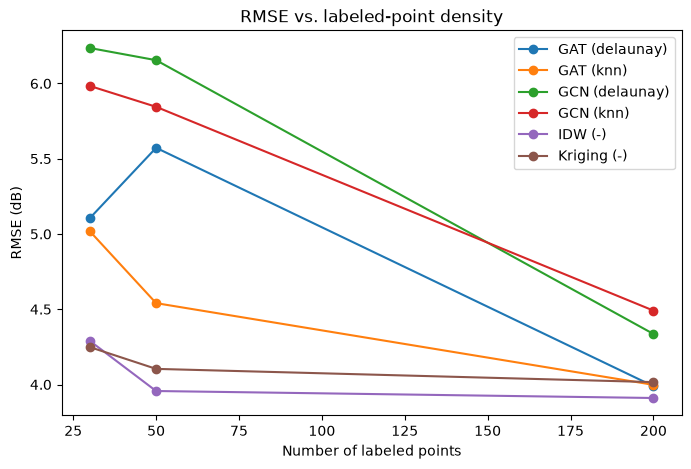

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
display(df)

fig, ax = plt.subplots(figsize=(8, 5))
for (model, topo), grp in df.groupby(["model", "topology"]):
    grp = grp.sort_values("density")
    ax.plot(grp["density"], grp["rmse"], marker="o", label=f"{model} ({topo})")
ax.set_xlabel("Number of labeled points")
ax.set_ylabel("RMSE (dB)")
ax.set_title("RMSE vs. labeled-point density")
ax.legend()
plt.show()


### 6c. Coverage accuracy metric

RMSE measures magnitude error but says nothing about whether a point is
correctly classified as "covered" vs. "outage" at a given receiver
sensitivity -- the metric the timeline actually calls for alongside RMSE.


In [14]:
def coverage_accuracy(rss_true, rss_pred, threshold_dbm):
    """Binary covered/outage classification accuracy at a sensitivity
    threshold. Complements RMSE, which only measures magnitude error."""
    true_covered = rss_true > threshold_dbm
    pred_covered = rss_pred > threshold_dbm
    return float((true_covered == pred_covered).mean())


def graph_topology_stats(edge_index, n_nodes):
    """Structural stats to help explain RMSE differences between kNN and
    Delaunay graphs (density/regularity of connectivity)."""
    deg = np.bincount(edge_index[0], minlength=n_nodes)
    return {
        "n_edges": edge_index.shape[1] // 2,
        "avg_degree": float(deg.mean()),
        "min_degree": int(deg.min()),
        "max_degree": int(deg.max()),
        "degree_std": float(deg.std()),
    }


### 6d. Full sweep across every scenario, with coverage accuracy

Extends `sweep()` to (a) run on every indoor scenario, not just
`SCENARIO_NAME`, and (b) record `coverage_acc` and topology structural
stats alongside `rmse` for every (scenario, density, topology, model)
combination.


In [15]:
def sweep_full(scenario_names=("i2_28b", "i1_2p5"), densities=(30, 50, 200),
               topologies=("knn", "delaunay"), n_seeds=3,
               coverage_threshold_dbm=None):
    all_results = []
    for scenario_name in scenario_names:
        positions, rss, feats = load_scenario(scenario_name)
        # per-scenario median RSS as a sensible default coverage cutoff if
        # you don't have a real receiver sensitivity spec to plug in
        thresh = coverage_threshold_dbm if coverage_threshold_dbm is not None else float(np.median(rss))

        for n_labeled in densities:
            for seed in range(n_seeds):
                train_idx, test_idx = make_split(len(positions), n_labeled, seed=seed)

                for topo in topologies:
                    edge_index = BUILDERS[topo](positions)
                    topo_stats = graph_topology_stats(edge_index, len(positions))

                    for name, model_cls in [("GCN", GCN), ("GAT", GAT)]:
                        pred, rmse = run_gnn(model_cls, positions, feats, rss,
                                              edge_index, train_idx, test_idx, seed=seed)
                        cov_acc = coverage_accuracy(rss[test_idx], pred[test_idx], thresh)
                        all_results.append({
                            "scenario": scenario_name, "density": n_labeled, "seed": seed,
                            "topology": topo, "model": name, "rmse": rmse, "coverage_acc": cov_acc,
                            **{f"topo_{k}": v for k, v in topo_stats.items()},
                        })

                idw_pred = idw_predict(positions[train_idx], rss[train_idx], positions[test_idx])
                all_results.append({
                    "scenario": scenario_name, "density": n_labeled, "seed": seed,
                    "topology": "-", "model": "IDW",
                    "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], idw_pred))),
                    "coverage_acc": coverage_accuracy(rss[test_idx], idw_pred, thresh),
                })

                krig_pred = kriging_predict(positions[train_idx], rss[train_idx], positions[test_idx])
                all_results.append({
                    "scenario": scenario_name, "density": n_labeled, "seed": seed,
                    "topology": "-", "model": "Kriging",
                    "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], krig_pred))),
                    "coverage_acc": coverage_accuracy(rss[test_idx], krig_pred, thresh),
                })
    return pd.DataFrame(all_results)


full_results = sweep_full()
summary = (full_results.groupby(["scenario", "density", "topology", "model"])
           .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                cov_mean=("coverage_acc", "mean"), cov_std=("coverage_acc", "std"))
           .reset_index())
display(summary)


Scenario "i2_28b" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 59.92it/s]


Scenario "i1_2p5" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i1_2p5: 80601 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 1) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 2) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 3) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 4) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 5) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 6) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 7) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 8) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 9) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 10) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 11) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 12) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_i

Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 1341.27it/s]


,scenario,density,topology,model,rmse_mean,rmse_std,cov_mean,cov_std
0,i1_2p5,30,-,IDW,1.116842,0.042341,0.826358,0.007319
1,i1_2p5,30,-,Kriging,1.176772,0.055891,0.815359,0.019659
2,i1_2p5,30,delaunay,GAT,1.661312,0.304283,0.709792,0.119383
3,i1_2p5,30,delaunay,GCN,1.568565,0.256607,0.757344,0.041015
4,i1_2p5,30,knn,GAT,1.370699,0.098192,0.777599,0.033754
5,i1_2p5,30,knn,GCN,1.517285,0.186713,0.768142,0.025709
6,i1_2p5,50,-,IDW,1.059688,0.042391,0.836835,0.003171
7,i1_2p5,50,-,Kriging,1.100988,0.043699,0.835825,0.012031
8,i1_2p5,50,delaunay,GAT,1.356316,0.211906,0.760741,0.043751
9,i1_2p5,50,delaunay,GCN,1.600049,0.245515,0.793266,0.016005


### 6e. Topology effect analysis

Quantifies the "kNN vs. Delaunay" comparison instead of leaving it as an
eyeballed guess: pivots RMSE by topology, holding scenario/density/model
fixed, so the size and direction of the topology effect is explicit.


In [16]:
def analyze_topology_effect(results_df):
    gnn_rows = results_df[results_df["topology"].isin(["knn", "delaunay"])]
    pivot = gnn_rows.pivot_table(index=["scenario", "density", "model"],
                                  columns="topology", values="rmse")
    pivot["delta_rmse (delaunay - knn)"] = pivot["delaunay"] - pivot["knn"]
    return pivot.sort_values("delta_rmse (delaunay - knn)")


analyze_topology_effect(full_results)


topology                delaunay       knn  delta_rmse (delaunay - knn)
scenario density model                                                 
i2_28b   200     GAT    3.997774  4.385887                    -0.388113
         30      GCN    6.390029  6.535569                    -0.145540
i1_2p5   50      GCN    1.600049  1.689661                    -0.089611
         200     GCN    1.015307  1.038764                    -0.023457
i2_28b   200     GCN    4.393049  4.394270                    -0.001221
i1_2p5   200     GAT    1.124086  1.085915                     0.038171
         30      GCN    1.568565  1.517285                     0.051280
         50      GAT    1.356316  1.295396                     0.060920
i2_28b   50      GCN    6.339853  6.234518                     0.105336
         30      GAT    5.900849  5.713560                     0.187290
i1_2p5   30      GAT    1.661312  1.370699                     0.290612
i2_28b   50      GAT    5.252018  4.801912                     0.450107

## 7. Generalization across indoor layouts

Train on one scenario, zero-shot evaluate on a different (unseen) layout.

### 7a. Two-way generalization sweep

Trains on one scenario and zero-shot evaluates on the other, in **both**
directions, across every topology/model combination, and reports coverage
accuracy alongside RMSE.

**Bug-fix pass:** normalization is now fit on the TRAIN scenario only and
the identical transform is applied to the TEST scenario, and predictions
are denormalized with those same TRAIN stats before computing RMSE/coverage.
The earlier version trained on each scenario's raw, unnormalized
coordinates/features, so at test time the model saw a scale its weights
were never trained on -- that's what produced RMSE of 30-100+ dB and
coverage_acc pinned at exactly 0.500 for every train/test combination.


In [17]:
def full_generalization_sweep(scenario_pairs=(("i2_28b", "i1_2p5"), ("i1_2p5", "i2_28b")),
                               topologies=("knn", "delaunay"),
                               models=(("GCN", GCN), ("GAT", GAT)),
                               epochs=300, lr=0.01, n_seeds=3):
    results = []
    cache = {}

    def get(name):
        if name not in cache:
            cache[name] = load_scenario(name)
        return cache[name]

    for train_scenario, test_scenario in scenario_pairs:
        pos_tr, rss_tr, feat_tr = get(train_scenario)
        pos_te, rss_te, feat_te = get(test_scenario)

        # Fit normalization on the TRAIN scenario only, then apply that
        # SAME transform to the test scenario. This is the fix: the old
        # version fed raw, unnormalized coordinates/features from each
        # scenario straight into the model, so at test time the model saw
        # a coordinate/feature scale its weights were never trained on --
        # that mismatch is what produced RMSE of 30-100+ dB and
        # coverage_acc pinned at exactly 0.500 for every combination
        # (a near-constant prediction is ~50% "correct" by construction
        # when the threshold is the test set's own median).
        stats = fit_normalizer(pos_tr, feat_tr, rss_tr)
        pos_tr_n, feat_tr_n, rss_tr_n = apply_normalizer(pos_tr, feat_tr, rss_tr, stats)
        pos_te_n, feat_te_n, _ = apply_normalizer(pos_te, feat_te, rss_te, stats)

        x_tr = torch.tensor(np.hstack([pos_tr_n, feat_tr_n]), dtype=torch.float32)
        y_tr = torch.tensor(rss_tr_n, dtype=torch.float32).unsqueeze(1)
        x_te = torch.tensor(np.hstack([pos_te_n, feat_te_n]), dtype=torch.float32)
        thresh_te = float(np.median(rss_te))

        for topo in topologies:
            ei_tr = torch.tensor(BUILDERS[topo](pos_tr), dtype=torch.long)
            ei_te = torch.tensor(BUILDERS[topo](pos_te), dtype=torch.long)

            for name, model_cls in models:
                for seed in range(n_seeds):
                    torch.manual_seed(seed)
                    model = model_cls(in_channels=x_tr.shape[1])
                    opt = torch.optim.Adam(model.parameters(), lr=lr)
                    loss_fn = nn.MSELoss()
                    for _ in range(epochs):
                        opt.zero_grad()
                        loss = loss_fn(model(x_tr, ei_tr), y_tr)
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                        opt.step()

                    with torch.no_grad():
                        pred_te_n = model(x_te, ei_te).numpy().squeeze()
                    # Denormalize with TRAIN stats -- using test-set stats
                    # here would just reintroduce the original mismatch.
                    pred_te = denormalize_rss(pred_te_n, stats)

                    rmse = float(np.sqrt(mean_squared_error(rss_te, pred_te)))
                    cov_acc = coverage_accuracy(rss_te, pred_te, thresh_te)
                    results.append({"train": train_scenario, "test": test_scenario,
                                     "topology": topo, "model": name, "seed": seed,
                                     "rmse": rmse, "coverage_acc": cov_acc})
                    print(f"[{name}/{topo} seed={seed}] {train_scenario} -> {test_scenario}: "
                          f"RMSE={rmse:.3f} dB, coverage_acc={cov_acc:.3f}")
    return pd.DataFrame(results)


generalization_results = full_generalization_sweep()
gen_summary = (generalization_results
               .groupby(["train", "test", "topology", "model"])
               .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                    cov_mean=("coverage_acc", "mean"), cov_std=("coverage_acc", "std"))
               .reset_index())
display(gen_summary)


Scenario "i2_28b" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 56.87it/s]


Scenario "i1_2p5" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i1_2p5: 80601 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 1) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 2) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 3) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 4) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 5) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 6) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 7) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 8) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 9) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 10) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 11) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 12) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_i

Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 1300.86it/s]


[GCN/knn seed=0] i2_28b -> i1_2p5: RMSE=317693342.685 dB, coverage_acc=0.500
[GCN/knn seed=1] i2_28b -> i1_2p5: RMSE=570321639.514 dB, coverage_acc=0.500
[GCN/knn seed=2] i2_28b -> i1_2p5: RMSE=145952769.782 dB, coverage_acc=0.500
[GAT/knn seed=0] i2_28b -> i1_2p5: RMSE=331213056.859 dB, coverage_acc=0.500
[GAT/knn seed=1] i2_28b -> i1_2p5: RMSE=3291361.088 dB, coverage_acc=0.500
[GAT/knn seed=2] i2_28b -> i1_2p5: RMSE=124091671.860 dB, coverage_acc=0.500
[GCN/delaunay seed=0] i2_28b -> i1_2p5: RMSE=102188919.055 dB, coverage_acc=0.500
[GCN/delaunay seed=1] i2_28b -> i1_2p5: RMSE=487941729.295 dB, coverage_acc=0.500
[GCN/delaunay seed=2] i2_28b -> i1_2p5: RMSE=55050427.733 dB, coverage_acc=0.500
[GAT/delaunay seed=0] i2_28b -> i1_2p5: RMSE=311596451.393 dB, coverage_acc=0.500
[GAT/delaunay seed=1] i2_28b -> i1_2p5: RMSE=16063051.389 dB, coverage_acc=0.500
[GAT/delaunay seed=2] i2_28b -> i1_2p5: RMSE=61404869.214 dB, coverage_acc=0.500
[GCN/knn seed=0] i1_2p5 -> i2_28b: RMSE=9287302.230

,train,test,topology,model,rmse_mean,rmse_std,cov_mean,cov_std
0,i1_2p5,i2_28b,delaunay,GAT,1.468833e+07,6.330359e+06,0.5,0.0
1,i1_2p5,i2_28b,delaunay,GCN,1.513400e+07,1.460321e+07,0.5,0.0
2,i1_2p5,i2_28b,knn,GAT,1.704096e+07,8.174019e+06,0.5,0.0
3,i1_2p5,i2_28b,knn,GCN,6.724053e+07,7.286921e+07,0.5,0.0
4,i2_28b,i1_2p5,delaunay,GAT,1.296881e+08,1.591601e+08,0.5,0.0
5,i2_28b,i1_2p5,delaunay,GCN,2.150604e+08,2.374946e+08,0.5,0.0
6,i2_28b,i1_2p5,knn,GAT,1.528654e+08,1.658436e+08,0.5,0.0
7,i2_28b,i1_2p5,knn,GCN,3.446559e+08,2.134654e+08,0.5,0.0


end of file